In [6]:
import numpy as np


def simulate_admixed_genetic_data(
    n=10_000,
    m=10_000,
    n_covariates=5,
    n_phenotypes=4,
    n_causal=100,
    amr_fraction=0.40,
    ancestry_switch_prob=0.002,
    ld_rho=0.90,
    phenotype_h2=0.50,
    seed=12345,
):
    """
    Simulate two-way AMR/EUR admixed genetic data with local ancestry,
    ancestry-specific dosages, covariates, and quantitative phenotypes.

    Each phenotype independently samples its own causal SNPs.
    """

    rng = np.random.default_rng(seed)

    if n_covariates != 5:
        raise ValueError("This implementation uses exactly 5 covariates.")
    if n_causal > m:
        raise ValueError("n_causal cannot exceed m.")

    h2 = np.asarray(phenotype_h2, dtype=float)
    if h2.ndim == 0:
        h2 = np.repeat(h2, n_phenotypes)
    if h2.shape != (n_phenotypes,) or np.any((h2 <= 0) | (h2 >= 1)):
        raise ValueError("phenotype_h2 must be in (0, 1) and have length n_phenotypes.")

    # Ancestry-specific MAFs
    base_maf = np.clip(rng.beta(1.5, 5.0, m), 0.03, 0.47)
    shift = rng.normal(0, 0.06, m)
    maf_amr = np.clip(base_maf + shift / 2, 0.01, 0.49)
    maf_eur = np.clip(base_maf - shift / 2, 0.01, 0.49)

    def simulate_haplotype():
        anc = np.empty((n, m), dtype=np.int8)
        allele = np.empty((n, m), dtype=np.int8)

        a = (rng.random(n) < amr_fraction).astype(np.int8)
        p = np.where(a, maf_amr[0], maf_eur[0])
        x = (rng.random(n) < p).astype(np.int8)

        anc[:, 0] = a
        allele[:, 0] = x

        for j in range(1, m):
            switch = rng.random(n) < ancestry_switch_prob
            a[switch] = (
                rng.random(switch.sum()) < amr_fraction
            ).astype(np.int8)

            p = np.where(a, maf_amr[j], maf_eur[j])
            prob = ld_rho * x + (1 - ld_rho) * p
            x = (rng.random(n) < prob).astype(np.int8)

            anc[:, j] = a
            allele[:, j] = x

        return anc, allele

    # Two haplotypes
    local_ancestry = np.empty((n, 2, m), dtype=np.int8)
    haplotype_alleles = np.empty((n, 2, m), dtype=np.int8)

    for h in range(2):
        print(f"Simulating haplotype {h + 1}/2...")
        local_ancestry[:, h], haplotype_alleles[:, h] = simulate_haplotype()

    # Dosages
    A = local_ancestry.sum(axis=1, dtype=np.int8)
    X = haplotype_alleles.sum(axis=1, dtype=np.int8)
    X_AMR = np.sum(
        haplotype_alleles * local_ancestry,
        axis=1,
        dtype=np.int8,
    )
    X_EUR = X - X_AMR

    # Basic consistency
    assert np.array_equal(X, X_AMR + X_EUR)
    assert np.all(X_AMR <= A)
    assert np.all(X_EUR <= 2 - A)

    # Covariates: 3 continuous + 2 binary
    Z = np.column_stack([
        rng.normal(50, 12, n),
        rng.normal(size=n),
        rng.normal(size=n),
        rng.binomial(1, 0.50, n),
        rng.binomial(1, 0.30, n),
    ]).astype(np.float32)

    Z[:, :3] = (
        Z[:, :3] - Z[:, :3].mean(axis=0)
    ) / Z[:, :3].std(axis=0)

    def standardize(M, idx):
        V = M[:, idx].astype(float)
        sd = V.std(axis=0)
        sd[sd < 1e-8] = 1
        return (V - V.mean(axis=0)) / sd

    # Causal variants
    n_A = n_causal // 3
    n_AMR = n_causal // 3
    n_EUR = n_causal - n_A - n_AMR

    genetic_score = np.zeros((n, n_phenotypes))
    causal = {}

    for k in range(n_phenotypes):
        snps = rng.choice(m, n_causal, replace=False)
        idx_A, idx_AMR, idx_EUR = np.split(
            snps,
            [n_A, n_A + n_AMR],
        )

        beta_A = rng.normal(0, 0.30, n_A)
        beta_AMR = rng.normal(0, 0.30, n_AMR)
        beta_EUR = rng.normal(0, 0.30, n_EUR)

        genetic_score[:, k] = (
            standardize(A, idx_A) @ beta_A
            + standardize(X_AMR, idx_AMR) @ beta_AMR
            + standardize(X_EUR, idx_EUR) @ beta_EUR
        )

        causal[f"phenotype_{k}"] = {
            "A": {"snp_indices": idx_A, "effects": beta_A},
            "X_AMR": {"snp_indices": idx_AMR, "effects": beta_AMR},
            "X_EUR": {"snp_indices": idx_EUR, "effects": beta_EUR},
        }

    # Covariate effects
    gamma_base = np.array([0.40, -0.25, 0.15, 0.50, -0.35])
    gamma = gamma_base[:, None] * rng.uniform(
        0.7,
        1.3,
        size=(1, n_phenotypes),
    )

    intercept = np.linspace(1.0, 2.5, n_phenotypes)

    # Noise calibrated to genetic h2
    genetic_var = genetic_score.var(axis=0)
    noise_var = genetic_var * (1 - h2) / h2
    noise = rng.normal(
        scale=np.sqrt(noise_var),
        size=(n, n_phenotypes),
    )

    Y = intercept + Z @ gamma + genetic_score + noise

    causal.update({
        "covariate_effects": gamma,
        "intercept": intercept,
        "phenotype_h2": h2,
    })

    return {
        "X": X,
        "A": A,
        "X_AMR": X_AMR,
        "X_EUR": X_EUR,
        "local_ancestry": local_ancestry,
        "haplotype_alleles": haplotype_alleles,
        "Z": Z,
        "Y": Y,
        "causal": causal,
        "maf_amr": maf_amr,
        "maf_eur": maf_eur,
    }

sim = simulate_admixed_genetic_data(
    n=10_000,
    m=10_000,
    n_phenotypes=4,
    n_causal=100,
    amr_fraction=0.40,
    ancestry_switch_prob=0.002,
    ld_rho=0.90,
    phenotype_h2=0.50,
    seed=2026,
)

X = sim["X"]
A = sim["A"]
X_AMR = sim["X_AMR"]
X_EUR = sim["X_EUR"]
Z = sim["Z"]
Y = sim["Y"]

print("X:", X.shape)
print("A:", A.shape)
print("X_AMR:", X_AMR.shape)
print("X_EUR:", X_EUR.shape)
print("Z:", Z.shape)
print("Y:", Y.shape)

print("AMR ancestry proportion:", A.mean() / 2)
print("Phenotype means:", Y.mean(axis=0))
print("Phenotype SDs:", Y.std(axis=0))

for k in range(Y.shape[1]):
    c = sim["causal"][f"phenotype_{k}"]
    print(
        f"Phenotype {k}:",
        len(c["A"]["snp_indices"]),
        len(c["X_AMR"]["snp_indices"]),
        len(c["X_EUR"]["snp_indices"]),
    )

Simulating haplotype 1/2...
Simulating haplotype 2/2...
X: (10000, 10000)
A: (10000, 10000)
X_AMR: (10000, 10000)
X_EUR: (10000, 10000)
Z: (10000, 5)
Y: (10000, 4)
AMR ancestry proportion: 0.39829362
Phenotype means: [1.12631884 1.63995078 2.16354825 2.62128065]
Phenotype SDs: [4.47146586 4.41861674 4.37995992 5.27171057]
Phenotype 0: 33 33 34
Phenotype 1: 33 33 34
Phenotype 2: 33 33 34
Phenotype 3: 33 33 34


In [7]:
import numpy as np
from scipy.linalg import solve_triangular

def precompute_tractor_stats(y, Z, A, X_AMR, X_EUR):
    """
    Precompute sufficient statistics for Tractor regression.

    y : (n,) or (n, p)
    Z : (n, q), including intercept
    A, X_AMR, X_EUR : (n, m)

    Returns phenotype statistics, adjusted SNP Gram statistics,
    and additive count statistics for downstream filtering.
    """

    y = np.asarray(y, dtype=float)
    Z = np.asarray(Z, dtype=float)

    if y.ndim == 1:
        y = y[:, None]
    if y.ndim != 2:
        raise ValueError("y must have shape (n,) or (n, p).")

    n, q = Z.shape
    m = A.shape[1]

    if y.shape[0] != n:
        raise ValueError("y and Z must have the same number of rows.")
    if A.shape[0] != n or X_AMR.shape != A.shape or X_EUR.shape != A.shape:
        raise ValueError("A, X_AMR, and X_EUR must all have shape (n, m).")

    p = y.shape[1]

    # Covariate adjustment
    ZtZ = Z.T @ Z
    L = np.linalg.cholesky(ZtZ)
    Linv = solve_triangular(L, np.eye(q), lower=True)

    zy = Linv @ (Z.T @ y)

    ZA = Linv @ (Z.T @ A)
    ZM = Linv @ (Z.T @ X_AMR)
    ZE = Linv @ (Z.T @ X_EUR)

    # y'M_Z y
    sy = np.sum(y * y, axis=0) - np.sum(zy * zy, axis=0)

    # G'M_Z y
    bA = A.T @ y - ZA.T @ zy
    bM = X_AMR.T @ y - ZM.T @ zy
    bE = X_EUR.T @ y - ZE.T @ zy

    # Additive count statistics
    sum_A = np.sum(A, axis=0, dtype=float)
    sum_X_AMR = np.sum(X_AMR, axis=0, dtype=float)
    sum_X_EUR = np.sum(X_EUR, axis=0, dtype=float)

    # Raw G'G statistics
    Af = A.astype(float)
    Mf = X_AMR.astype(float)
    Ef = X_EUR.astype(float)

    AA = np.sum(Af * Af, axis=0)
    MM = np.sum(Mf * Mf, axis=0)
    EE = np.sum(Ef * Ef, axis=0)

    AM = np.sum(Af * Mf, axis=0)
    AE = np.sum(Af * Ef, axis=0)
    ME = np.sum(Mf * Ef, axis=0)

    # G'M_Z G
    s11 = AA - np.sum(ZA * ZA, axis=0)
    s22 = MM - np.sum(ZM * ZM, axis=0)
    s33 = EE - np.sum(ZE * ZE, axis=0)

    s12 = AM - np.sum(ZA * ZM, axis=0)
    s13 = AE - np.sum(ZA * ZE, axis=0)
    s23 = ME - np.sum(ZM * ZE, axis=0)

    return {
        "n": n,
        "q": np.linalg.matrix_rank(ZtZ),
        "p": p,
        "m": m,

        "Linv": Linv,
        "sy": sy,

        "bA": bA,
        "bM": bM,
        "bE": bE,

        "s11": s11,
        "s22": s22,
        "s33": s33,
        "s12": s12,
        "s13": s13,
        "s23": s23,

        "sum_A": sum_A,
        "sum_X_AMR": sum_X_AMR,
        "sum_X_EUR": sum_X_EUR,
    }

In [8]:
import numpy as np
from scipy.stats import t as t_dist


def tractor_from_precomputed(stats, det_tol=1e-12, count_threshold=20):
    """
    Tractor association testing from precomputed sufficient statistics.

    Supports multiple phenotypes:
        bA, bM, bE : (m, p)

    SNPs are valid only if:
        - abs(det(S)) > det_tol
        - AMR/EUR haplotype counts >= count_threshold
        - AMR/EUR ALT and REF counts >= count_threshold
    """

    n, q = stats["n"], stats["q"]

    sy = np.atleast_1d(np.asarray(stats["sy"], float))
    bA = np.asarray(stats["bA"], float)
    bM = np.asarray(stats["bM"], float)
    bE = np.asarray(stats["bE"], float)

    if bA.ndim == 1:
        bA = bA[:, None]
        bM = bM[:, None]
        bE = bE[:, None]

    m, p = bA.shape

    s11, s22, s33 = (
        np.asarray(stats[k], float)
        for k in ("s11", "s22", "s33")
    )
    s12, s13, s23 = (
        np.asarray(stats[k], float)
        for k in ("s12", "s13", "s23")
    )

    # ------------------------------------------------------------
    # Counts
    # ------------------------------------------------------------

    sum_A = np.asarray(stats["sum_A"], float)
    sum_M = np.asarray(stats["sum_X_AMR"], float)
    sum_E = np.asarray(stats["sum_X_EUR"], float)

    n_AMR = sum_A
    n_EUR = 2 * n - sum_A

    alt_AMR = sum_M
    ref_AMR = sum_A - sum_M

    alt_EUR = sum_E
    ref_EUR = 2 * n - sum_A - sum_E

    # ------------------------------------------------------------
    # Cofactors and determinant
    # ------------------------------------------------------------

    c11 = s22 * s33 - s23**2
    c22 = s11 * s33 - s13**2
    c33 = s11 * s22 - s12**2

    c12 = s13 * s23 - s12 * s33
    c13 = s12 * s23 - s13 * s22
    c23 = s12 * s13 - s11 * s23

    det = s11 * c11 + s12 * c12 + s13 * c13

    valid_design = (
        np.isfinite(det)
        & (np.abs(det) > det_tol)
    )

    if count_threshold is None:
        valid_counts = np.ones(m, dtype=bool)
    else:
        valid_counts = (
            (n_AMR >= count_threshold)
            & (n_EUR >= count_threshold)
            & (alt_AMR >= count_threshold)
            & (ref_AMR >= count_threshold)
            & (alt_EUR >= count_threshold)
            & (ref_EUR >= count_threshold)
        )

    valid = valid_design & valid_counts

    # ------------------------------------------------------------
    # Betas
    # ------------------------------------------------------------

    beta_A = np.full((m, p), np.nan)
    beta_M = np.full((m, p), np.nan)
    beta_E = np.full((m, p), np.nan)

    d = det[valid, None]

    beta_A[valid] = (
        c11[valid, None] * bA[valid]
        + c12[valid, None] * bM[valid]
        + c13[valid, None] * bE[valid]
    ) / d

    beta_M[valid] = (
        c12[valid, None] * bA[valid]
        + c22[valid, None] * bM[valid]
        + c23[valid, None] * bE[valid]
    ) / d

    beta_E[valid] = (
        c13[valid, None] * bA[valid]
        + c23[valid, None] * bM[valid]
        + c33[valid, None] * bE[valid]
    ) / d

    # ------------------------------------------------------------
    # RSS and variance
    # ------------------------------------------------------------

    RSS = np.full((m, p), np.nan)

    RSS[valid] = (
        sy[None, :]
        - beta_A[valid] * bA[valid]
        - beta_M[valid] * bM[valid]
        - beta_E[valid] * bE[valid]
    )

    RSS[valid] = np.maximum(RSS[valid], 0)

    df = n - q - 3
    sigma2 = RSS / df

    # ------------------------------------------------------------
    # SEs
    # ------------------------------------------------------------

    inv11 = np.full(m, np.nan)
    inv22 = np.full(m, np.nan)
    inv33 = np.full(m, np.nan)

    inv11[valid] = c11[valid] / det[valid]
    inv22[valid] = c22[valid] / det[valid]
    inv33[valid] = c33[valid] / det[valid]

    se_A = np.sqrt(sigma2 * inv11[:, None])
    se_M = np.sqrt(sigma2 * inv22[:, None])
    se_E = np.sqrt(sigma2 * inv33[:, None])

    # ------------------------------------------------------------
    # t and p
    # ------------------------------------------------------------

    t_A = beta_A / se_A
    t_M = beta_M / se_M
    t_E = beta_E / se_E

    p_A = 2 * t_dist.sf(np.abs(t_A), df)
    p_M = 2 * t_dist.sf(np.abs(t_M), df)
    p_E = 2 * t_dist.sf(np.abs(t_E), df)

    return {
        "beta_A": beta_A,
        "beta_AMR": beta_M,
        "beta_EUR": beta_E,

        "se_A": se_A,
        "se_AMR": se_M,
        "se_EUR": se_E,

        "t_A": t_A,
        "t_AMR": t_M,
        "t_EUR": t_E,

        "p_A": p_A,
        "p_AMR": p_M,
        "p_EUR": p_E,

        "RSS": RSS,
        "sigma2": sigma2,
        "df": df,

        "det": det,
        "valid": valid,
        "valid_design": valid_design,
        "valid_counts": valid_counts,

        "n_AMR_haps": n_AMR,
        "n_EUR_haps": n_EUR,
        "alt_AMR": alt_AMR,
        "ref_AMR": ref_AMR,
        "alt_EUR": alt_EUR,
        "ref_EUR": ref_EUR,
    }

In [9]:
Z_reg = np.column_stack([
    np.ones(Y.shape[0]),
    Z,
])

stats = precompute_tractor_stats(
    y=Y,
    Z=Z_reg,
    A=A,
    X_AMR=X_AMR,
    X_EUR=X_EUR,
)

gwas = tractor_from_precomputed(
    stats,
    count_threshold=20,
    det_tol=1e-6,
)

In [10]:
import numpy as np
import matplotlib.pyplot as plt


def plot_tractor_manhattan_with_truth(
    sim,
    results,
    bonferroni=True,
    point_size=10,
    causal_size=70,
):
    """Plot A, AMR, and EUR Tractor results separately for each phenotype."""

    p_A = np.atleast_2d(results["p_A"])
    if p_A.shape[0] == 1:
        p_A = p_A.T

    m, n_phenotypes = p_A.shape
    snp = np.arange(m)
    threshold = -np.log10(0.05 / m)

    panels = [
        ("A", "p_A", "Local ancestry effect"),
        ("X_AMR", "p_AMR", "AMR-specific allele effect"),
        ("X_EUR", "p_EUR", "EUR-specific allele effect"),
    ]

    for k in range(n_phenotypes):
        fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
        truth = sim["causal"][f"phenotype_{k}"]

        for ax, (causal_key, p_key, title) in zip(axes, panels):
            p = np.asarray(results[p_key])
            if p.ndim == 1:
                p = p[:, None]
            p = p[:, k]

            valid = np.isfinite(p) & (p > 0)
            logp = np.full(m, np.nan)
            logp[valid] = -np.log10(
                np.maximum(p[valid], np.finfo(float).tiny)
            )

            ax.scatter(
                snp[valid],
                logp[valid],
                s=point_size,
                alpha=0.55,
            )

            causal = np.asarray(truth[causal_key]["snp_indices"])
            causal_valid = np.isfinite(p[causal]) & (p[causal] > 0)

            ax.scatter(
                causal[causal_valid],
                logp[causal[causal_valid]],
                s=causal_size,
                facecolors="none",
                edgecolors="black",
                linewidths=1.5,
                label="True causal SNP",
            )

            if bonferroni:
                ax.axhline(
                    threshold,
                    linestyle="--",
                    linewidth=1.25,
                    label=f"Bonferroni: 0.05/{m:,}",
                )

            ax.set(
                title=title,
                ylabel=r"$-\log_{10}(p)$",
            )
            ax.legend(frameon=False, loc="upper right")

        axes[-1].set_xlabel("SNP index")
        fig.suptitle(
            f"Tractor-style association scan with true causal SNPs — Phenotype {k}",
            fontsize=15,
        )
        fig.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

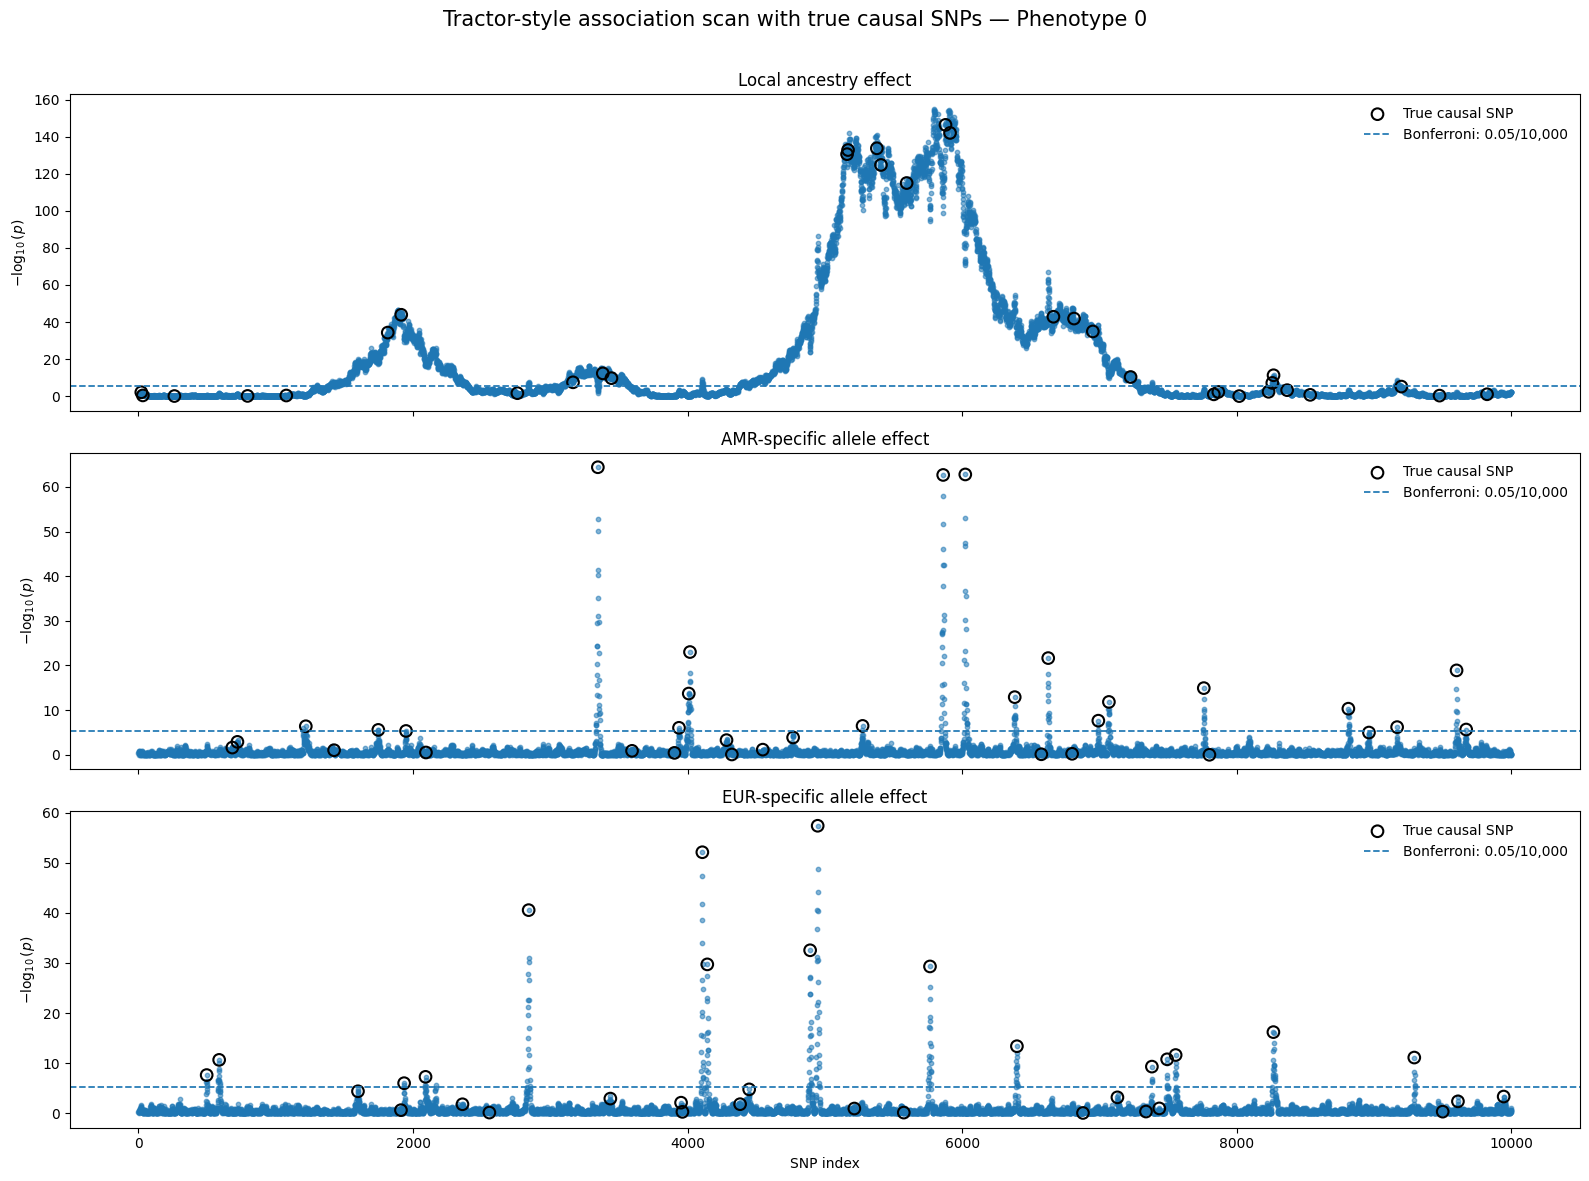

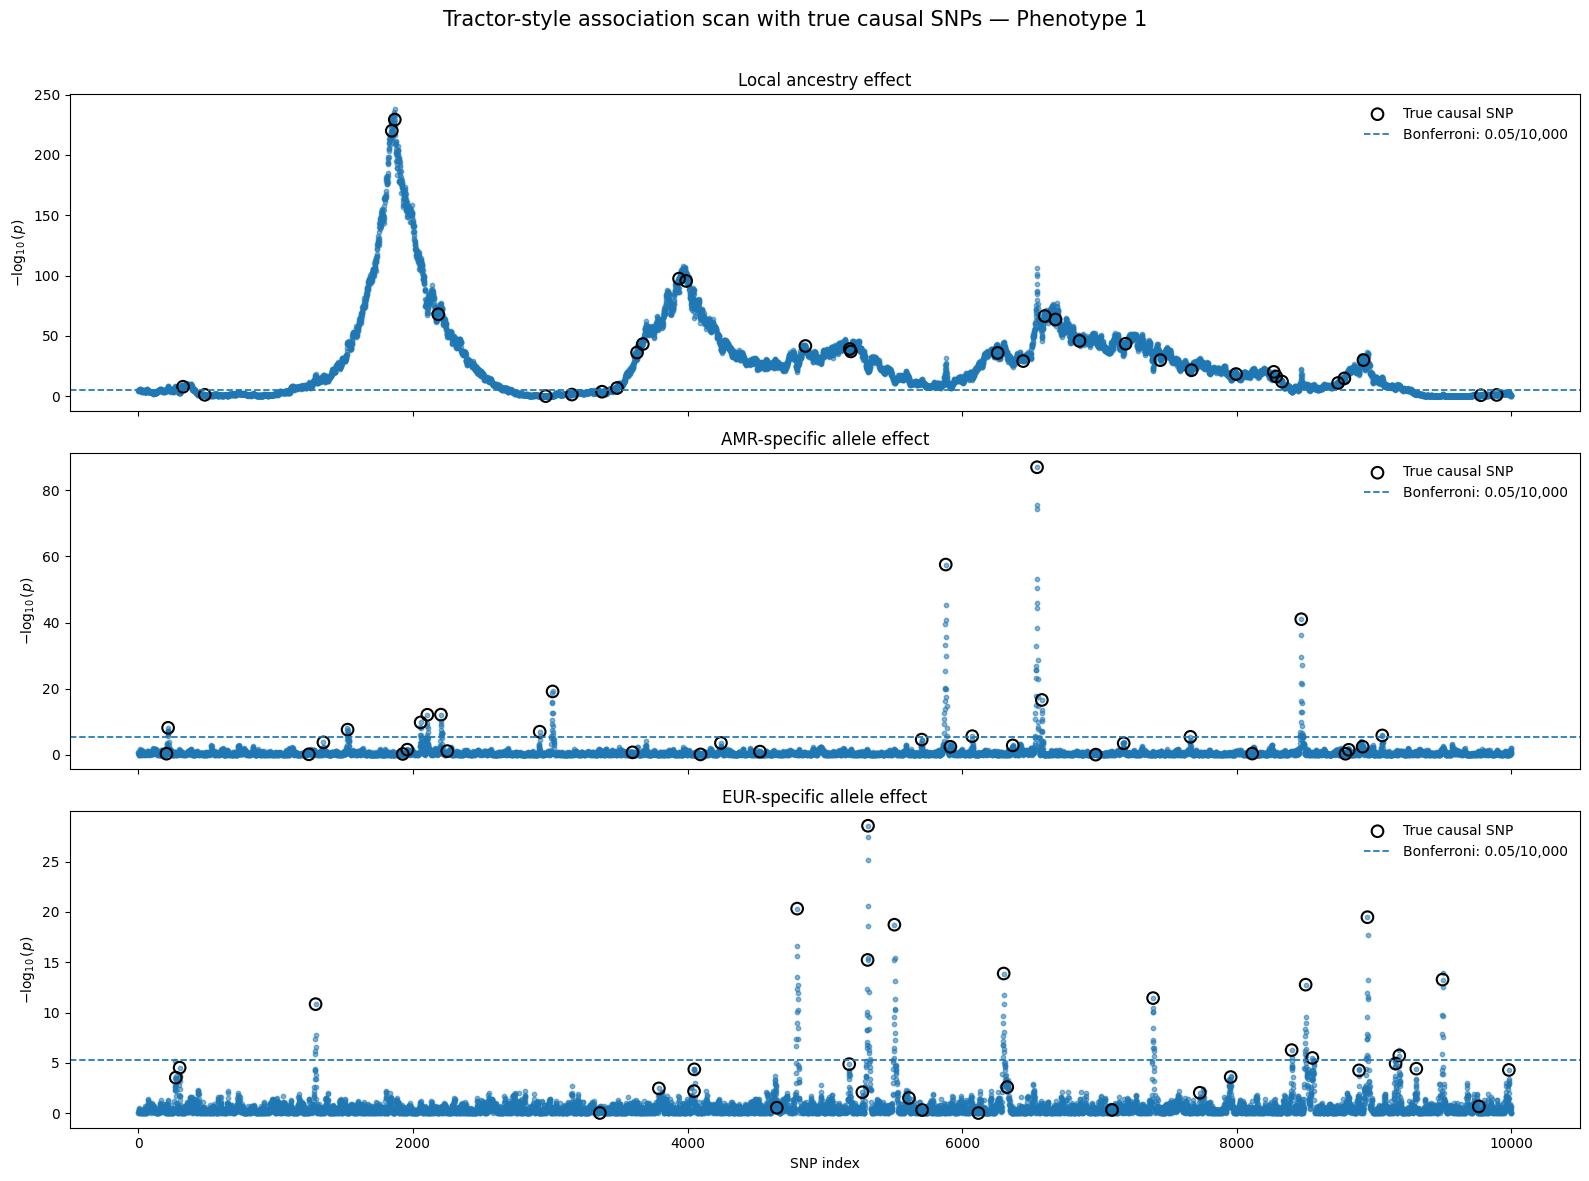

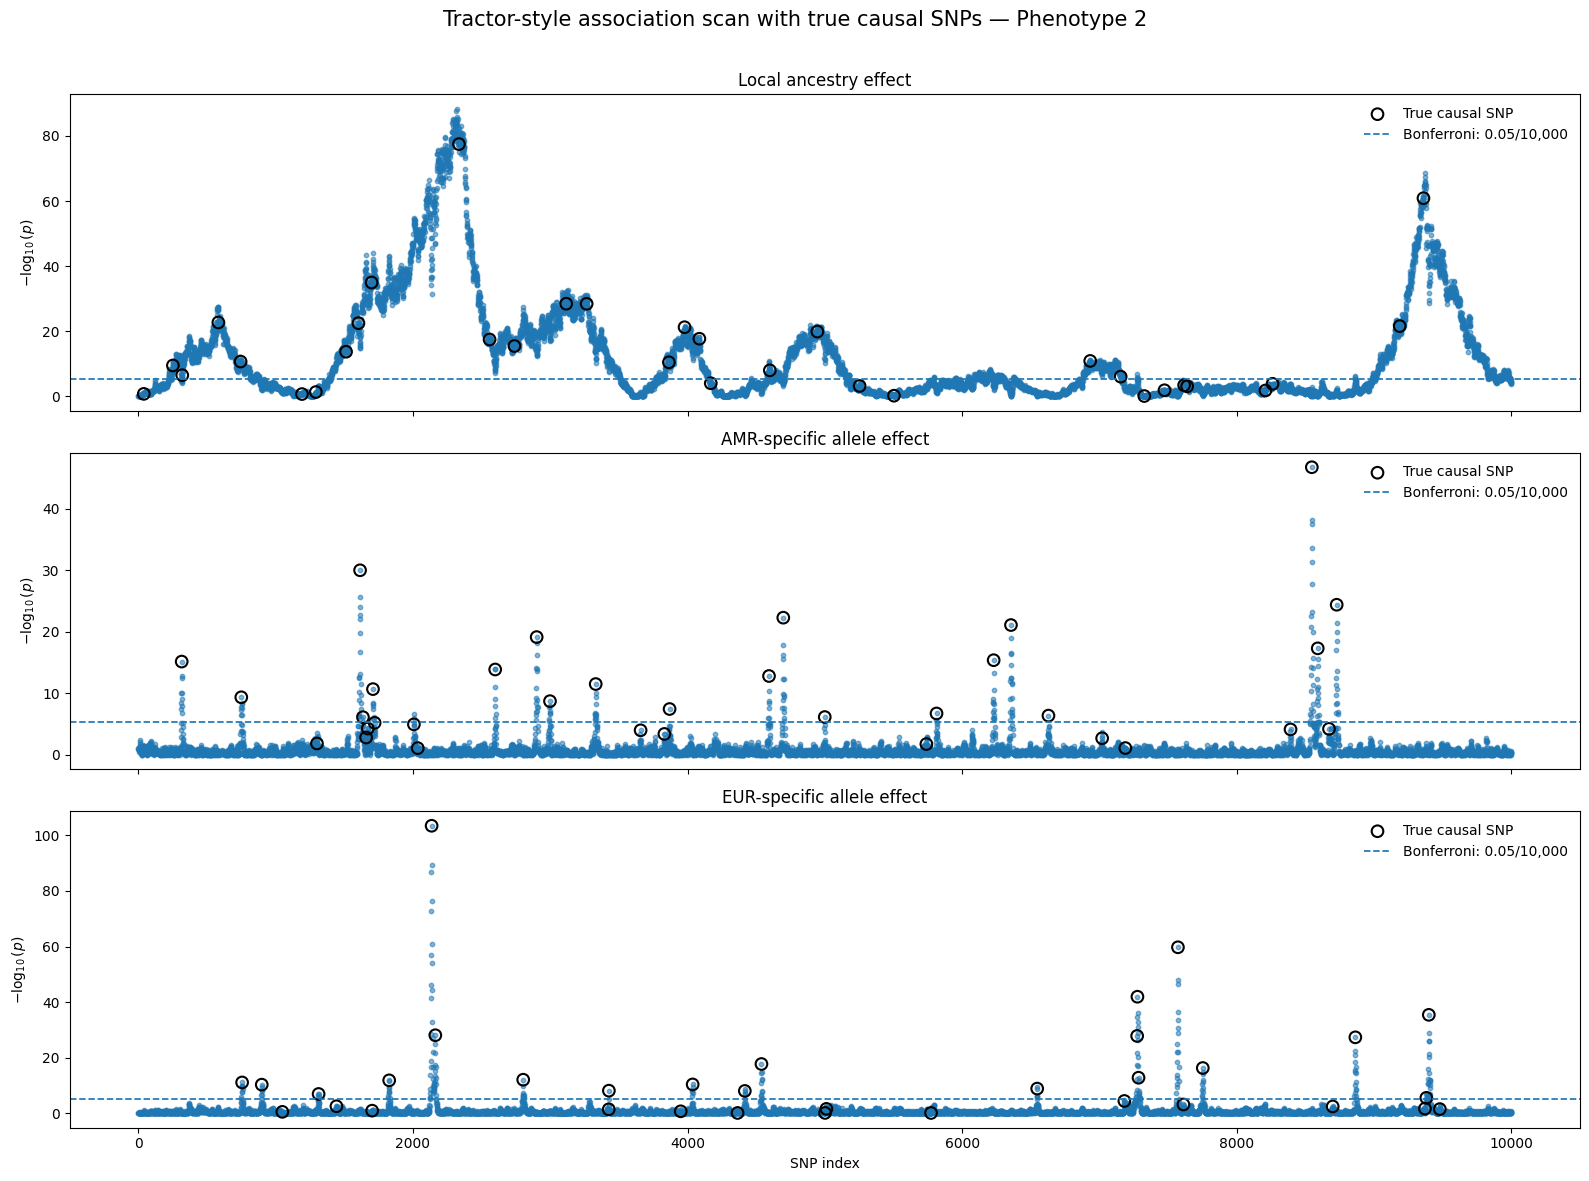

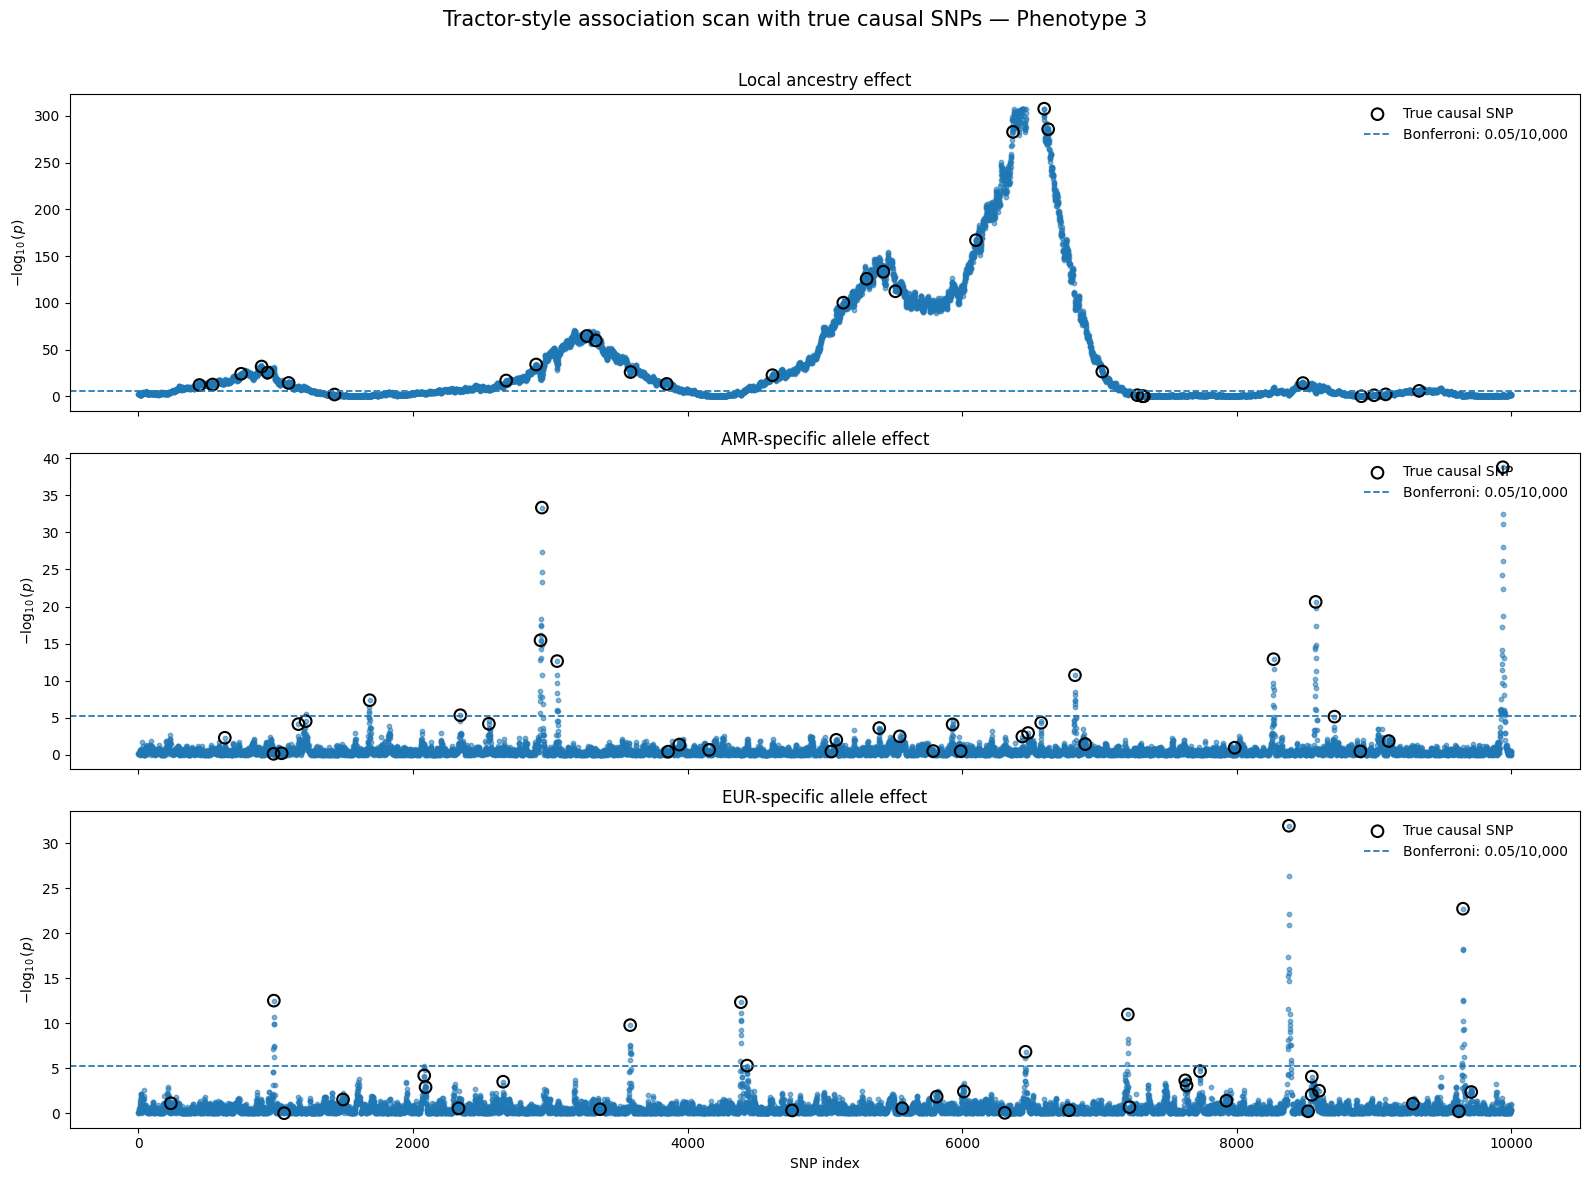

In [11]:
# Run
plot_tractor_manhattan_with_truth(
    sim,
    gwas
)

In [12]:
import os
import gzip
import time
import numpy as np
import pandas as pd


def export_simulation_for_tractor(
    sim,
    outdir="tractor_sim",
    prefix="simulated",
    chunk_size=1000,
    compresslevel=1,
):
    """Export AMR/EUR simulation to Tractor files with progress reporting."""

    os.makedirs(outdir, exist_ok=True)

    A = sim["A"]
    X_AMR = sim["X_AMR"]
    X_EUR = sim["X_EUR"]
    Z = sim["Z"]
    Y = np.asarray(sim["Y"])

    if Y.ndim == 1:
        Y = Y[:, None]

    n, m = A.shape
    p = Y.shape[1]

    samples = [f"sample{i}" for i in range(n)]
    chrom = np.ones(m, dtype=int)
    pos = 1_000_000 + 100 * np.arange(m)
    ids = np.array([f"snp{j}" for j in range(m)])
    ref = np.repeat("A", m)
    alt = np.repeat("G", m)

    # Variant map
    variant_map = os.path.join(outdir, f"{prefix}.variant_map.tsv")
    pd.DataFrame({
        "CHROM": chrom,
        "POS": pos,
        "ID": ids,
        "REF": ref,
        "ALT": alt,
        "SNP_index": np.arange(m),
    }).to_csv(variant_map, sep="\t", index=False)

    # Phenotypes + covariates
    pheno = pd.DataFrame({"IID": samples})
    for k in range(p):
        pheno[f"Y{k}"] = Y[:, k]
    for k in range(Z.shape[1]):
        pheno[f"Z{k + 1}"] = Z[:, k]

    pheno_file = os.path.join(outdir, f"{prefix}.pheno.tsv.gz")
    pheno.to_csv(
        pheno_file,
        sep="\t",
        index=False,
        compression={"method": "gzip", "compresslevel": compresslevel},
    )

    def write_matrix(matrix, filename, complement=False):
        path = os.path.join(outdir, filename)
        t0 = time.perf_counter()

        print(f"\nWriting {filename}")

        with gzip.open(path, "wt", compresslevel=compresslevel) as f:
            for start in range(0, m, chunk_size):
                end = min(start + chunk_size, m)

                values = matrix[:, start:end].T
                if complement:
                    values = 2 - values

                block = pd.DataFrame(values, columns=samples)
                block.insert(0, "ALT", alt[start:end])
                block.insert(0, "REF", ref[start:end])
                block.insert(0, "ID", ids[start:end])
                block.insert(0, "POS", pos[start:end])
                block.insert(0, "CHROM", chrom[start:end])

                block.to_csv(
                    f,
                    sep="\t",
                    index=False,
                    header=(start == 0),
                )

                elapsed = time.perf_counter() - t0
                pct = 100 * end / m
                rate = end / elapsed

                print(
                    f"\r  {end:,}/{m:,} SNPs "
                    f"({pct:5.1f}%) | "
                    f"{rate:,.0f} SNP/s",
                    end="",
                    flush=True,
                )

        elapsed = time.perf_counter() - t0
        size_gb = os.path.getsize(path) / 1e9

        print(
            f"\n  done in {elapsed:.1f}s | "
            f"{size_gb:.2f} GB"
        )

        return path

    t0 = time.perf_counter()

    files = {
        "anc0_dosage": write_matrix(
            X_AMR,
            f"{prefix}.anc0.dosage.txt.gz",
        ),
        "anc1_dosage": write_matrix(
            X_EUR,
            f"{prefix}.anc1.dosage.txt.gz",
        ),
        "anc0_hapcount": write_matrix(
            A,
            f"{prefix}.anc0.hapcount.txt.gz",
        ),
        "anc1_hapcount": write_matrix(
            A,
            f"{prefix}.anc1.hapcount.txt.gz",
            complement=True,
        ),
    }

    print(
        f"\nAll files complete in "
        f"{(time.perf_counter() - t0) / 60:.1f} min"
    )

    return {
        "prefix": os.path.join(outdir, prefix),
        "phenofile": pheno_file,
        "variant_map": variant_map,
        "phenotypes": [f"Y{k}" for k in range(p)],
        **files,
    }

In [13]:
## EXPORT SIMULATED DATA TO DISK (COMMENT OUT AFTER RUNNING ONCE)
# tractor_files = export_simulation_for_tractor(
#     sim,
#     outdir="tractor_sim",
#     prefix="simulated",
#     chunk_size=1000,
#     compresslevel=1,
# )

In [14]:
## INSTALL TRACTOR (COMMENT OUT AFTER RUNNING ONCE)
# !git clone https://github.com/Atkinson-Lab/Tractor.git
# !cd Tractor && conda env create -f conda_py3_tractor_mac.yml

In [15]:
phenotypes = ["Y0", "Y1", "Y2", "Y3"]

for pheno in phenotypes:
    !cd Tractor && conda run -n py3_tractor Rscript scripts/run_tractor.R \
        --hapdose ../tractor_sim/simulated \
        --phenofile ../tractor_sim/simulated.pheno.tsv.gz \
        --covarcollist Z1,Z2,Z3,Z4,Z5 \
        --method linear \
        --output ../tractor_sim/tractor_results_{pheno}.txt \
        --sampleidcol IID \
        --phenocol {pheno} \
        --chunksize 1000 \
        --nthreads 4

Tractor Script Version : 1.4.0 
Sample ID column used  :  IID 
Phenotype column used  :  Y0 
Covariates used        : Z1 Z2 Z3 Z4 Z5 
Total hapcount/dosage files identified  : 4 
                         ../tractor_sim/simulated.anc0.hapcount.txt.gz 
                         ../tractor_sim/simulated.anc1.hapcount.txt.gz 
                         ../tractor_sim/simulated.anc0.dosage.txt.gz 
                         ../tractor_sim/simulated.anc1.dosage.txt.gz 
Total SNPs Identified  : 10000 
Threads being used     : 3 
Total samples          : 10000 (from hapcount/dosage files)

Chunk 1/10 completed.     2026-09-02 07:18:04.099587 
Chunk 2/10 completed.     2026-09-02 07:18:14.110391 
Chunk 3/10 completed.     2026-09-02 07:18:23.806264 
Chunk 4/10 completed.     2026-09-02 07:18:33.507424 
Chunk 5/10 completed.     2026-09-02 07:18:43.315123 
Chunk 6/10 completed.     2026-09-02 07:18:53.205539 
Chunk 7/10 completed.     2026-09-02 07:19:03.269313 
Chunk 8/10 completed.     2026-09-02 0

In [16]:
import numpy as np
import pandas as pd


def read_tractor_results_multi(
    tractor_files,
    variant_map_file=None,
):
    """
    Read one Tractor output file per phenotype and return arrays
    aligned as (m, p).

    Assumes:
        anc0 = AMR
        anc1 = EUR
    """

    rename = {
        "beta_anc0": "beta_AMR",
        "se_anc0": "se_AMR",
        "pval_anc0": "p_AMR",
        "beta_anc1": "beta_EUR",
        "se_anc1": "se_EUR",
        "pval_anc1": "p_EUR",
        "LAeff_anc0": "beta_A",
        "LApval_anc0": "p_A",
    }

    vm = None
    if variant_map_file is not None:
        vm = pd.read_csv(variant_map_file, sep="\t")[["ID", "SNP_index"]]

    dfs = []

    for f in tractor_files:
        tr = pd.read_csv(f, sep="\t").rename(columns=rename)

        if vm is not None:
            tr = (
                tr.merge(vm, on="ID", how="left")
                .sort_values("SNP_index")
                .reset_index(drop=True)
            )

        dfs.append(tr)

    keys = [
        "beta_A", "beta_AMR", "beta_EUR",
        "se_AMR", "se_EUR",
        "p_A", "p_AMR", "p_EUR",
    ]

    out = {
        k: np.column_stack([df[k].to_numpy() for df in dfs])
        for k in keys
        if all(k in df.columns for df in dfs)
    }

    out["dataframes"] = dfs
    return out

In [17]:
tractor = read_tractor_results_multi(
    tractor_files=[
        "tractor_sim/tractor_results_Y0.txt",
        "tractor_sim/tractor_results_Y1.txt",
        "tractor_sim/tractor_results_Y2.txt",
        "tractor_sim/tractor_results_Y3.txt",
    ],
    variant_map_file="tractor_sim/simulated.variant_map.tsv",
)

In [18]:
def compare_tractor_to_gwas(tractor, gwas):
    rows = []

    for effect in ["A", "AMR", "EUR"]:
        for stat in ["beta", "p"]:
            key = f"{stat}_{effect}"

            if key not in tractor or key not in gwas:
                continue

            x = np.asarray(gwas[key])
            y = np.asarray(tractor[key])

            for k in range(x.shape[1]):
                valid = np.isfinite(x[:, k]) & np.isfinite(y[:, k])

                rows.append({
                    "phenotype": k,
                    "effect": effect,
                    "stat": stat,
                    "n": valid.sum(),
                    "max_abs_diff": np.max(
                        np.abs(x[valid, k] - y[valid, k])
                    ),
                    "mean_abs_diff": np.mean(
                        np.abs(x[valid, k] - y[valid, k])
                    ),
                    "correlation": np.corrcoef(
                        x[valid, k], y[valid, k]
                    )[0, 1],
                })

    return pd.DataFrame(rows)


comparison = compare_tractor_to_gwas(
    tractor,
    gwas,
)

comparison

,phenotype,effect,stat,n,max_abs_diff,mean_abs_diff,correlation
0,0,A,beta,10000,4.999965e-07,2.484048e-07,1.0
1,1,A,beta,10000,4.999031e-07,2.496448e-07,1.0
2,2,A,beta,10000,4.999554e-07,2.493278e-07,1.0
3,3,A,beta,10000,5.000537e-07,2.493496e-07,1.0
4,0,A,p,10000,2.341775e-09,1.714932e-10,1.0
5,1,A,p,10000,3.916860e-09,1.074055e-10,1.0
6,2,A,p,10000,3.809309e-09,1.272388e-10,1.0
7,3,A,p,10000,3.175668e-09,1.298170e-10,1.0
8,0,AMR,beta,10000,5.001426e-07,2.486413e-07,1.0
9,1,AMR,beta,10000,5.007861e-07,2.522391e-07,1.0


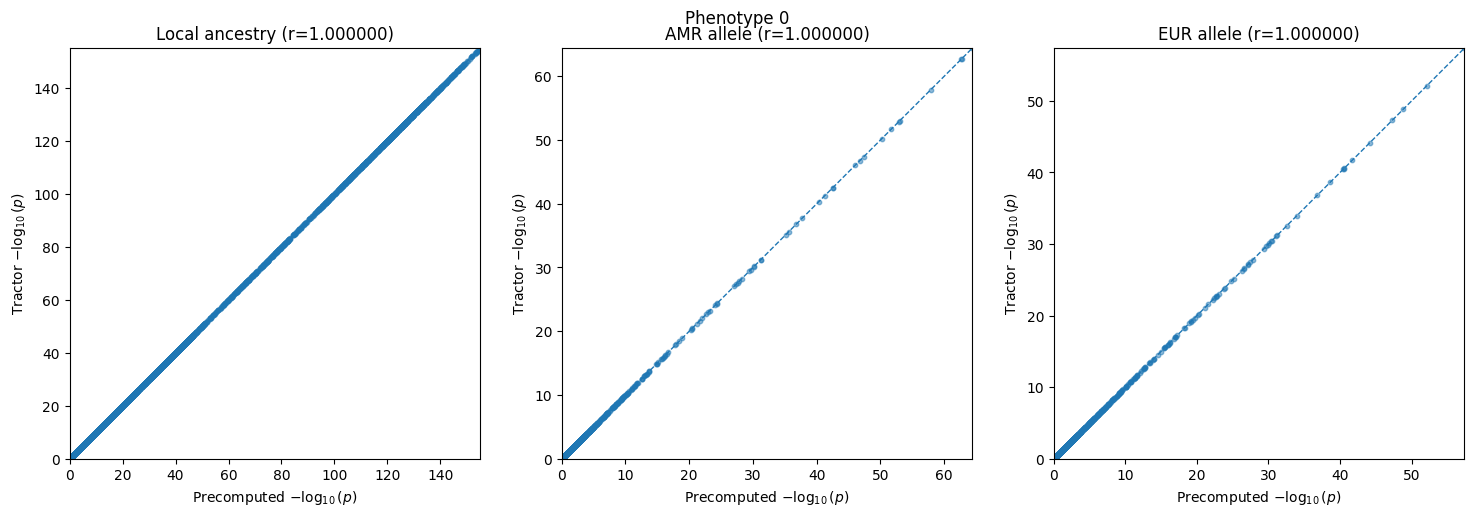

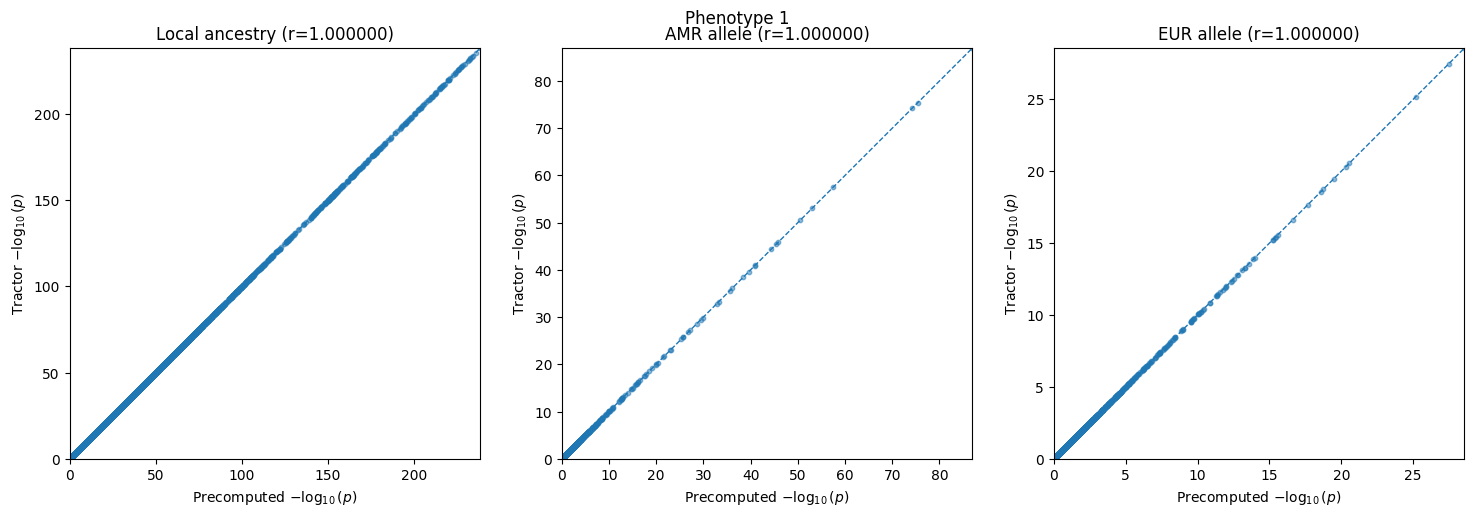

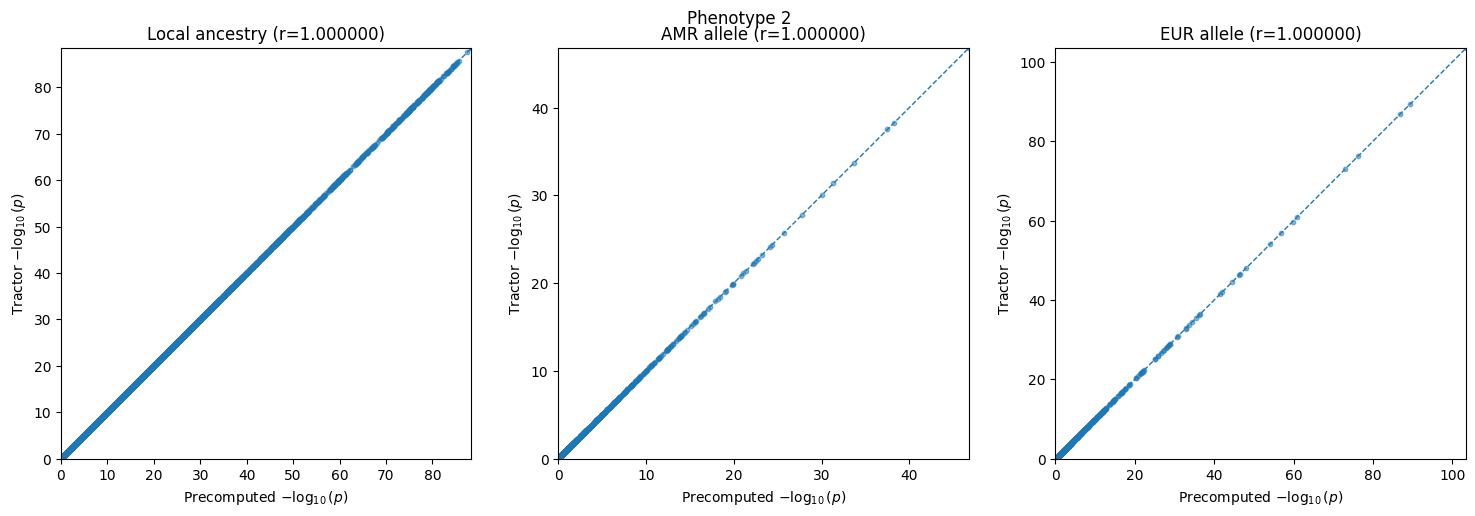

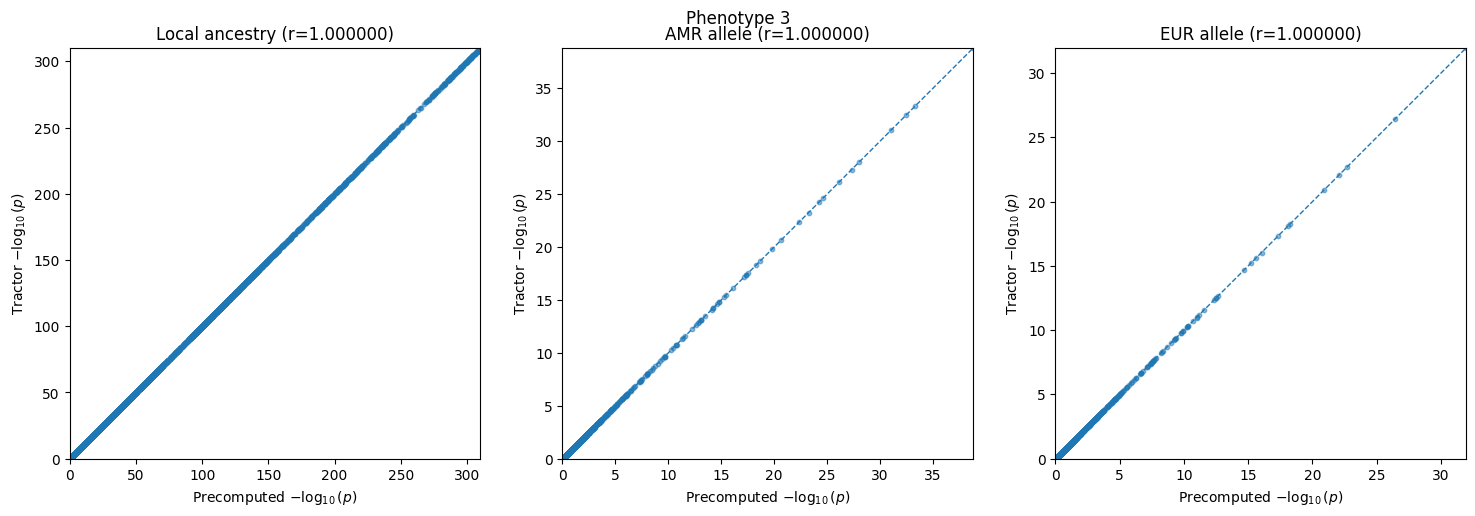

In [19]:
import numpy as np
import matplotlib.pyplot as plt


def plot_pvalue_comparison(tractor, gwas):
    panels = [
        ("p_A", "Local ancestry"),
        ("p_AMR", "AMR allele"),
        ("p_EUR", "EUR allele"),
    ]

    P = np.asarray(gwas["p_A"])
    if P.ndim == 1:
        P = P[:, None]

    _, n_pheno = P.shape

    for k in range(n_pheno):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        for ax, (key, title) in zip(axes, panels):
            x = np.asarray(gwas[key])
            y = np.asarray(tractor[key])

            if x.ndim == 1:
                x, y = x[:, None], y[:, None]

            x, y = x[:, k], y[:, k]
            valid = (
                np.isfinite(x) & np.isfinite(y)
                & (x > 0) & (y > 0)
            )

            x = -np.log10(x[valid])
            y = -np.log10(y[valid])

            ax.scatter(x, y, s=10, alpha=0.5)

            lim = max(x.max(), y.max())
            ax.plot([0, lim], [0, lim], "--", linewidth=1)

            r = np.corrcoef(x, y)[0, 1]

            ax.set(
                title=f"{title} (r={r:.6f})",
                xlabel=r"Precomputed $-\log_{10}(p)$",
                ylabel=r"Tractor $-\log_{10}(p)$",
                xlim=(0, lim),
                ylim=(0, lim),
            )
            ax.set_aspect("equal", adjustable="box")

        fig.suptitle(f"Phenotype {k}")
        fig.tight_layout()
        plt.show()


plot_pvalue_comparison(tractor, gwas)